In [94]:
import pandas as pd
import os
from cyvcf2 import VCF
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"current working directory: {os.getcwd()}")

current working directory: /Users/cbrown/code/cse_284


In [95]:
# tools
bcftools="./tools/bcftools/bin/bcftools"
plink="./tools/plink2/plink2"

In [96]:
# paths
sum_stats_path = "data/raw/1_CRC_SNPs_list_205_Nature_2023.xlsx"
vcf_path = "data/processed/GenRisk_all_CRC_SNPs_perm.clean.vcf.gz"
pheno_path = "data/raw/GenRisk_ImputedData_CRC_Samples.txt"

# Import & preprocess

In [97]:
# gwas summary results for crc associated snps
df_sum_stats = pd.read_excel(sum_stats_path)
print(df_sum_stats.shape)
df_sum_stats['chr_pos'] = df_sum_stats.CHR.astype('str') + '_' + df_sum_stats['POS (GRCh37)'].astype('str')
df_sum_stats = df_sum_stats.set_index('chr_pos')
df_sum_stats.head(1)

(205, 15)


,CHR,POS (GRCh37),VARIANT,rsID,EFFECT_ALLELE,OTHER_ALLELE,BETA,SE,P,REF,PMID,PMCID,DOI,PUBLISHED_SNP,LD across all included populations
chr_pos,,,,,,,,,,,,,,,
1_22503282,1,22503282,1:22503282_G/C,rs2807367,C,G,-0.0379,6.8999999999999999E-3,3.2700000000000002E-8,"Al-Tassan NA, Sci Rep, 2015",25990418.0,PMC4438486,10.1038/srep10442,rs72647484,R2:0.01; D':0.78


In [98]:
vcf = VCF(vcf_path)
print(f"{len(vcf.samples)} samples")

4104 samples


In [99]:
print("Before filtering")
df_pheno = pd.read_csv(pheno_path, sep='\t', index_col=0)
print(df_pheno.value_counts())
print()
df_pheno = df_pheno.loc[vcf.samples]
print("After filtering")
print(df_pheno.value_counts())

Before filtering
tipo_cancer
Control        2864
Colorectal     1431
Name: count, dtype: int64

After filtering
tipo_cancer
Control        2864
Colorectal     1240
Name: count, dtype: int64


In [100]:
df_post_qc = pd.read_excel('/Users/cbrown/code/cse_284/data/processed/Effect allele count.xlsx')
snp_cols = df_post_qc.iloc[:,6:].columns
snp_cols = [f"{s.split(':')[0]}_{s.split(':')[1].split('_')[0]}" for s in snp_cols]
print(snp_cols[:10])
has_duplicates = len(snp_cols) != len(set(snp_cols))
print(has_duplicates)

['1_22503282', '1_22710877', '1_38461319', '1_55247852', '1_62673037', '1_71040166', '1_110365045', '1_172864224', '1_183056222', '1_201885446']
False


# Make all effect allele's positive

In [101]:
def positive_effects(row):
    if row.BETA < 0:
        row.EFFECT_ALLELE, row.OTHER_ALLELE = row.OTHER_ALLELE, row.EFFECT_ALLELE
        row.BETA *= -1
    return row

df_sum_stats = df_sum_stats.apply(positive_effects, axis=1)
df_sum_stats.head()

,CHR,POS (GRCh37),VARIANT,rsID,EFFECT_ALLELE,OTHER_ALLELE,BETA,SE,P,REF,PMID,PMCID,DOI,PUBLISHED_SNP,LD across all included populations
chr_pos,,,,,,,,,,,,,,,
1_22503282,1,22503282,1:22503282_G/C,rs2807367,G,C,0.03790,6.8999999999999999E-3,3.2700000000000002E-8,"Al-Tassan NA, Sci Rep, 2015",25990418.0,PMC4438486,10.1038/srep10442,rs72647484,R2:0.01; D':0.78
1_22710877,1,22710877,1:22710877_G/C,rs34963268,G,C,0.06589,8.4200000000000004E-3,5.0699999999999999E-15,NEW,NaN,NaN,NaN,NaN,NaN
1_38461319,1,38461319,1:38461319_C/A,rs61776719,C,A,0.05610,6.7000000000000002E-3,4.67E-17,"Huyghe JR, Nat Genet, 2019",30510241.0,PMC6358437,10.1038/s41588-018-0286-6,rs4360494,R2:0.95; D':0.98
1_55247852,1,55247852,1:55247852_A/G,rs12143541,G,A,0.08250,0.01,1.2800000000000001E-16,"Huyghe JR, Nat Genet, 2019",30510241.0,PMC6358437,10.1038/s41588-018-0286-6,rs12144319,R2:0.12; D':1
1_62673037,1,62673037,1:62673037_T/C,rs7542665,C,T,0.01850,6.8999999999999999E-3,7.6800000000000002E-3,"Lu Y, Gastro, 2019",30529582.0,PMC6441622,10.1053/j.gastro.2018.11.066,rs7542665,R2:1; D':1


# Build alt allele count table

In [102]:
CHR_POS = []
SAMPLE_IDS = vcf.samples
COLUMNS = []

for variant in vcf:
    if variant.INFO['MAF'] < 0.005:
        continue
    chrom, pos, ref, alt = variant.CHROM, variant.POS, variant.REF, variant.ALT
    CHR_POS.append(str(chrom) + '_' + str(pos))
    # check if effect allele is alt allele
    subset = df_sum_stats.loc[(df_sum_stats.CHR == chrom) & (df_sum_stats['POS (GRCh37)'] == pos)]
    assert len(subset) == 1
    subset = subset.iloc[0]
    sums = []
    for a,b,_ in variant.genotypes:
        if subset.EFFECT_ALLELE == alt:
            sums.append(a+b)
        else:
            sums.append(2 - a - b)
    COLUMNS.append(sums)

df_alt_counts = pd.DataFrame(data = COLUMNS, index = CHR_POS, columns=SAMPLE_IDS).T
df_alt_counts.head()

,1_22503282,1_22710877,1_38461319,1_55247852,1_62673037,1_71040166,1_110365045,1_172864224,1_183056222,1_201885446,...,8_128413305,8_128414892,8_128581578,9_22105927,9_34107505,9_101679752,9_110373819,9_113654654,9_136682468,9_136925663
A00002,0,2,1,2,0,1,1,2,1,1,...,2,0,1,0,2,2,2,1,2,2
A00005,0,0,2,2,1,2,2,1,1,2,...,0,1,2,1,1,2,2,2,0,2
A00011,0,2,0,2,0,2,0,1,0,1,...,1,0,1,0,2,2,2,2,2,1
A00012,1,2,2,2,2,2,2,0,1,1,...,1,0,2,1,2,2,1,2,2,2
A00014,0,2,1,2,0,1,1,2,0,1,...,2,0,1,0,1,2,1,2,2,2


# Calculate PRS

In [108]:
# reindex alt_counts to those that passed qc
df_alt_counts = df_alt_counts.reindex(columns=snp_cols)

# align sum stats with alt_counts
df_sum_stats = df_sum_stats.reindex(df_alt_counts.columns)
df_sum_stats = df_sum_stats.reindex()

# dot product of sum stats BETA by genotypes
results = df_alt_counts.dot(df_sum_stats.BETA)
print(results.describe())

results.name = 'PRS'
df_results = results.to_frame()
df_results = df_results.merge(df_pheno, left_index=True, right_index=True)

count    4104.000000
mean       17.139462
std         0.536812
min        15.225731
25%        16.781496
50%        17.144650
75%        17.508742
max        18.990433
dtype: float64


In [119]:
df_sum_stats.BETA

1_22503282     0.03790
1_22710877     0.06589
1_38461319     0.05610
1_55247852     0.08250
1_62673037     0.01850
                ...   
9_101679752    0.06010
9_110373819    0.06050
9_113654654    0.04780
9_136682468    0.07362
9_136925663    0.05266
Name: BETA, Length: 199, dtype: float64

In [109]:
scaler = StandardScaler()
df_results['PRS_scaled'] = scaler.fit_transform(df_results[['PRS']])

In [110]:
df_results.groupby('tipo_cancer')['PRS_scaled'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_cancer,,,,,,,,
Colorectal,1240.0,0.037036,1.008296,-2.938898,-0.648311,0.058559,0.729893,3.448502
Control,2864.0,-0.016035,0.996312,-3.565429,-0.679706,-0.002880,0.673533,3.073646


<Axes: xlabel='PRS_scaled'>

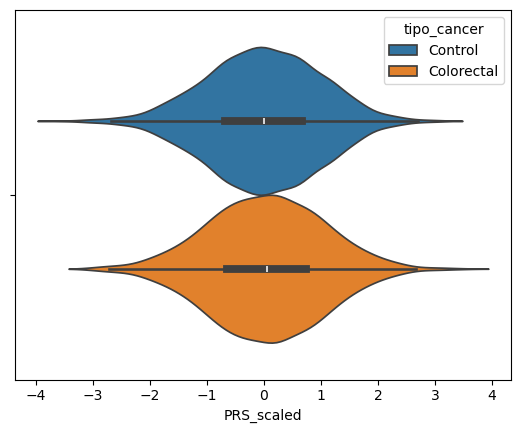

In [111]:
sns.violinplot(df_results, x='PRS_scaled',hue='tipo_cancer')

<Axes: xlabel='PRS_scaled', ylabel='Density'>

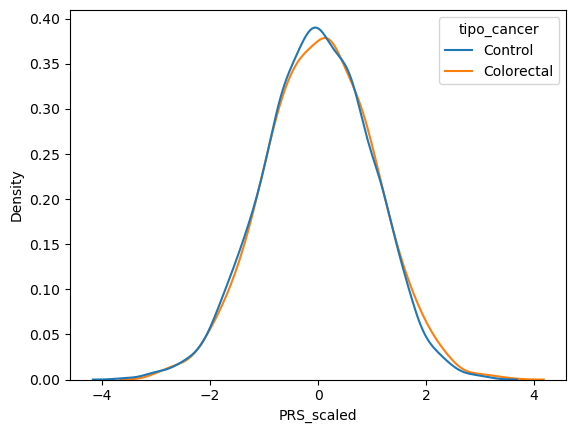

In [112]:
sns.kdeplot(df_results,x='PRS_scaled',hue='tipo_cancer', common_norm=False)